<a href="https://colab.research.google.com/github/maria-isabel-castano/Repositorio_IA/blob/main/Checkpoint_1_N2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Primer flujo de IA usando técnicas de programación avanzada**

**Objetivo general**

Desarrollar un mini-proyecto completo en
Python que integre: funciones, programación funcional, POO,
decoradores, manejo de archivos, excepciones, Pandas,
scikit-learn y guardado del modelo.



---


**Fuente de datos:**

https://docs.google.com/spreadsheets/d/e/2PACX-1vTAe9Ng_y_eXr1PWu8PoQ7xahwtDSlbiKlZzkQD_7aCI6Mm3jll5tjpf7Xo1dhylH6p3gjjt-IGm7hJ/pub?gid=207319265&single=true&output=csv



#**Importar librerías**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from datetime import datetime, timedelta
from functools import wraps
import time
import random
import pickle
import logging

# --- Configuración básica del logger ---
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')
logging.info('Librerías importadas correctamente')

# **Carga de datos desde el enlace publicado**

Se aplica manejo de archivos y validación con excepciones (`try-except`) para asegurar que el dataset se cargue correctamente.

In [ ]:
# --- Manejo avanzado de excepciones ---
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vTAe9Ng_y_eXr1PWu8PoQ7xahwtDSlbiKlZzkQD_7aCI6Mm3jll5tjpf7Xo1dhylH6p3gjjt-IGm7hJ/pub?gid=207319265&single=true&output=csv'

try:
  df = pd.read_csv(url)
  logging.info('Dataset cargado correctamente')
except Exception as e:
  logging.error(f'Error al cargar el dataset: {e}')

df.head(10)

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89
5,2005,Women,Training,Flex Trainer,M,1.0,7363.96,NaN,0.0,NaN,Retail,Delhi,1415.98
6,2006,Men,Training,SuperRep Go,M,NaN,6819.78,NaN,0.0,04-06-2025,Online,Bangalore,1802.09
7,2007,Kids,Training,SuperRep Go,M,1.0,NaN,0.32,0.0,NaN,Retail,Bangalore,2928.36
8,2008,Women,Soccer,Premier III,11,-1.0,NaN,NaN,0.0,11-10-2024,Online,Hyderabad,-731.18
9,2009,Men,Soccer,Mercurial Superfly,M,4.0,NaN,NaN,0.0,NaN,Online,Pune,3929.61


In [ ]:
df.tail(10)

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
2490,4490,Women,Training,Metcon 7,L,0.0,NaN,NaN,0.0,23-02-2025,Online,Kolkata,-1173.84
2491,4491,Women,Running,Pegasus Turbo,M,0.0,NaN,NaN,0.0,NaN,Online,Kolkata,3066.85
2492,4492,Men,Lifestyle,Air Force 1,M,NaN,NaN,NaN,0.0,NaN,Retail,Mumbai,2397.23
2493,4493,Women,Lifestyle,Blazer Mid,XL,4.0,NaN,NaN,0.0,2024-10-04,Online,Mumbai,321.24
2494,4494,Women,Training,ZoomX Invincible,L,NaN,NaN,NaN,0.0,12-02-2025,Online,Kolkata,1357.29
2495,4495,Kids,Basketball,Kyrie Flytrap,XL,3.0,NaN,NaN,0.0,2025-05-14,Online,Pune,2.97
2496,4496,Men,Basketball,Kyrie Flytrap,L,-1.0,NaN,NaN,0.0,NaN,Online,Hyd,-487.36
2497,4497,Men,Soccer,Tiempo Legend,7,NaN,6647.60,0.52,0.0,02-07-2025,Retail,Bangalore,-918.14
2498,4498,Women,Training,ZoomX Invincible,NaN,4.0,5358.70,NaN,0.0,11-12-2024,Online,Mumbai,3352.29
2499,4499,Women,Running,Air Zoom,M,NaN,5550.99,NaN,0.0,23-11-2024,Retail,Mumbai,2453.57


# **Exploración inicial y limpieza de datos**

Se inspecciona la estructura del dataset.

Con la función `.info()` se revisan valores nulos y el tipo de datos.

La función `.isna().sum()` nos muestra la suma total de los valores nulos en cada columna del conjunto de datos.

Con esta función `.duplicated().sum()` podemos ver la cantidad de filas duplicadas que tenemos.

Finalmente, la función `.describe()` nos muestra estadísticas descriptivas como media, desviación estándar, entre otras.

In [ ]:
df.info()
print('\nValores nulos por columna:\n', df.isna().sum())
print('\nFilas duplicadas:', df.duplicated().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB

Valores nulos por columna:
 Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name        

,Order_ID,Units_Sold,MRP,Discount_Applied,Revenue,Profit
count,2500.000000,1265.000000,1246.000000,832.000000,2500.000000,2500.000000
mean,3194.352400,1.482213,6039.863395,0.631022,274.873716,1376.012848
std,749.972638,1.696947,2315.746826,0.365500,2023.773550,1478.671013
min,2000.000000,-1.000000,2006.630000,0.000000,-7561.590000,-1199.450000
25%,2534.750000,0.000000,4038.902500,0.320000,0.000000,93.532500
50%,3192.500000,2.000000,6110.030000,0.615000,0.000000,1371.385000
75%,3841.250000,3.000000,8022.187500,0.962500,0.000000,2660.645000
max,4499.000000,4.000000,9996.220000,1.250000,37169.350000,3999.210000


In [ ]:
def summarize_columns_stats(df_input, *column_names):
    """Calcula y muestra la media, mediana y desviación estándar de columnas numéricas"""
    for col in column_names:
        if col in df_input.columns:
            logging.info(f'\n--- Estadísticas para la columna: {col} ---')
            logging.info(f'  Media: {df_input[col].mean():.2f}')
            logging.info(f'  Mediana: {df_input[col].median():.2f}')
            logging.info(f'  Desviación Estándar: {df_input[col].std():.2f}')
        else:
            logging.warning(f'La columna "{col}" no se encontró en el DataFrame.')

# --- LLamar la funcion para resumir las estadísticas de columnas relevantes ---
summarize_columns_stats(df, 'Units_Sold', 'MRP', 'Profit')

def handle_negative_units_sold(value):
    """Retorna 0 si el valor es negativo, de lo contrario devuelve el valor original."""
    return max(0, value)

# --- Programación funcional en la variable 'Units_Sold'
df['Units_Sold'] = df['Units_Sold'].map(handle_negative_units_sold)
logging.info('Valores negativos en "Units_Sold" convertidos a 0.')

# --- Verificación que no haya valores negativos en 'Units_Sold'
logging.info('\nEstadísticas descriptivas de "Units_Sold" después de la corrección:')
logging.info(df['Units_Sold'].describe().to_string())


La función `.isnull()` nos muestra en forma de DataFrame los valores nulos del dataset en valores de True (si el valor es nulo) y False (si el valor no es nulo).

In [ ]:
df.isnull()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,False,False,False,False,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,True,True,False,True,False,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False,False
4,False,False,False,False,False,False,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,False,False,False,False,False,False,True,True,False,False,False,False,False
2496,False,False,False,False,False,False,True,True,False,True,False,False,False
2497,False,False,False,False,False,False,False,False,False,False,False,False,False
2498,False,False,False,False,True,False,False,True,False,False,False,False,False


## **Limpieza de datos: valores nulos, duplicados y valores atípicos**

Una vez identificados los problemas del dataset, el siguiente paso es corregirlos.
En este código se realiza el relleno de valores nulos con estrategias adecuadas:

- Para textos, se asigna la etiqueta "Desconocido".
- Para valores numéricos, se usa la mediana de la columna.
- Finalmente, se muestra el dataset limpio y listo para análisis o modelado.

Además se analizarán los outliers con diagramas de boxplots para una mejor visualización.

### **Outliers:**

Identificación de valores atípicos o fuera de rango de nuestro conjunto de datos con visualización usando la gráfica tipo boxplot.

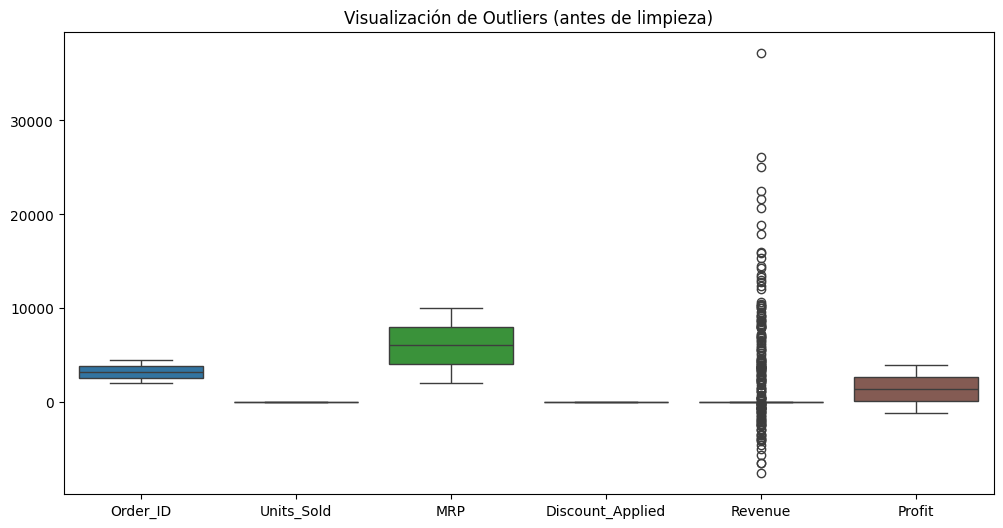

In [ ]:
# --- Visualización de outliers ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['Order_ID', 'Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Profit']])
plt.title('Visualización de Outliers (antes de limpieza)')
plt.show()

La variable `'Revenue'` tiene muchos outliers, por lo tanto lo analizaremos un poco más.

In [ ]:
# --- Ver los datos dentro de la variable 'Revenue' ---
unique_revenue_df = pd.DataFrame({'Revenue_Values': df['Revenue'].unique()})
display(unique_revenue_df)

,Revenue_Values
0,0.00
1,6910.22
2,-2409.48
3,2514.99
4,-169.59
...,...
162,4995.81
163,-2158.22
164,9981.04
165,-2370.08


In [ ]:
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1

df_outliers = df[(df['Revenue'] < Q1 - 1.5 * IQR) |
                 (df['Revenue'] > Q3 + 1.5 * IQR)]
df_outliers


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
16,2016,Women,Basketball,Air Jordan,M,1.0,9871.75,0.30,6910.22,NaN,Retail,hyderbad,2452.69
21,2021,Men,Running,Free RN,L,0.0,7086.70,0.66,-2409.48,2024/11/19,Retail,Hyd,-1120.49
31,2031,Men,Soccer,Premier III,NaN,4.0,3493.04,0.82,2514.99,2024-05-09,Online,Delhi,350.70
37,2037,Kids,Running,Pegasus Turbo,7,3.0,5653.14,1.01,-169.59,NaN,Retail,Pune,2776.96
57,2048,Men,Lifestyle,Waffle One,M,3.0,6216.29,0.94,1118.93,2024/09/14,Online,Mumbai,-642.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2446,4446,Men,Soccer,Mercurial Superfly,M,2.0,3469.31,0.28,4995.81,2025/01/26,Retail,Pune,2671.58
2457,2019,Men,Lifestyle,Air Force 1,L,0.0,2452.52,0.12,-2158.22,26-07-2024,Retail,Hyd,-1199.45
2463,4463,Men,Soccer,Premier III,11,3.0,8317.53,0.60,9981.04,07-06-2025,Retail,Pune,1821.65
2468,4468,Men,Soccer,Premier III,XL,3.0,6077.13,1.13,-2370.08,2023-11-27,Online,Mumbai,3173.31


> **`'Revenue'`:**
Esta variable muestra que los valores en el 75% de sus cuartiles tienen un valor de 0.
Por el momento no se va a tratar esta columna pues aún no logro entender bien su relevancia con las demás variables.

### **Valores nulos:**

Se van a tratar los valores nulos:

- Con la media se reemplazarán los valores de las columnas numéricas: `'Units_Sold'`, `'Discount_Applied'`, `'MRP'`.

- Los datos de la variable `'Size'` se reemplazarán con la palabra `'Unknown'`

In [ ]:
# --- Suma y porcentaje de valores nulos del dataset ---
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

# --- Organizar la suma y porcentaje de valores nulos en forma descendente ---
resumen_nulos = pd.DataFrame({
    'Valores_Nulos': nulos,
    'Porcentaje_%': porcentaje_nulos
}).sort_values(by='Valores_Nulos', ascending=False)

print("Resumen de valores nulos:\n")
print(resumen_nulos)

Resumen de valores nulos:

                  Valores_Nulos  Porcentaje_%
Discount_Applied           1668         66.72
MRP                        1254         50.16
Order_Date                  616         24.64
Size                        510         20.40
Order_ID                      0          0.00
Product_Name                  0          0.00
Product_Line                  0          0.00
Gender_Category               0          0.00
Units_Sold                    0          0.00
Revenue                       0          0.00
Sales_Channel                 0          0.00
Region                        0          0.00
Profit                        0          0.00


In [ ]:
# --- Reemplazar valores nulos ---
df['Units_Sold'].fillna(df['Units_Sold'].mean(), inplace=True)
df['Discount_Applied'].fillna(df['Discount_Applied'].mean(), inplace=True)
df['MRP'].fillna(df['MRP'].mean(), inplace=True)
df['Size'].fillna('Unknown', inplace=True)

df

/tmp/ipython-input-2289749893.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Units_Sold'].fillna(df['Units_Sold'].mean(), inplace=True)
/tmp/ipython-input-2289749893.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,0.0,6039.863395,0.470000,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.930000,0.631022,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,6039.863395,0.631022,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,0.0,9673.570000,0.631022,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,0.0,6039.863395,0.631022,0.0,2024/09/12,Retail,Delhi,187.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,4495,Kids,Basketball,Kyrie Flytrap,XL,3.0,6039.863395,0.631022,0.0,2025-05-14,Online,Pune,2.97
2496,4496,Men,Basketball,Kyrie Flytrap,L,0.0,6039.863395,0.631022,0.0,NaN,Online,Hyd,-487.36
2497,4497,Men,Soccer,Tiempo Legend,7,0.0,6647.600000,0.520000,0.0,02-07-2025,Retail,Bangalore,-918.14
2498,4498,Women,Training,ZoomX Invincible,Unknown,4.0,5358.700000,0.631022,0.0,11-12-2024,Online,Mumbai,3352.29


### **Manejo de fechas:**

Se completarán los valores nulos de la columna `'Order_Date'` con fechas aleatorias y se les dará el formato YYYY-MM-DD.

In [ ]:
df["Order_Date"] = [
    (datetime.today() - timedelta(days=random.randint(0, 1000)))
    .strftime("%Y-%m-%d") # Formato de fecha fijo
    for _ in range(len(df))
]

df['Order_Date'].head(15)

,Order_Date
0,2025-11-11
1,2025-07-15
2,2023-06-14
3,2024-02-05
4,2023-11-15
5,2023-09-19
6,2025-05-19
7,2025-03-15
8,2023-05-15
9,2024-02-05


In [ ]:
# --- Verificación que los datos nulos en la fecha se hayan solucionado ---
print(f"Valores nulos en 'Order_Date' después del procesamiento: {df['Order_Date'].isnull().sum()}")

Valores nulos en 'Order_Date' después del procesamiento: 0


### **Estandarizar escritura de la variable `'Region'`:**

Al visualizar el DataFrame, se pudo observar que la columna `'Region'` presenta valores que están escritos de diferente forma: abreviaciones, primera letra en minúscula o mayúscula.

In [ ]:
# --- Ver que datos contiene la variable 'Region' ---
region_df = pd.DataFrame({'Region': df['Region'].unique()})
display(region_df)

,Region
0,bengaluru
1,Hyd
2,Mumbai
3,Pune
4,Delhi
5,Bangalore
6,Hyderabad
7,hyderbad
8,Kolkata


In [ ]:
# --- Mapeo de regiones inconsistentes a un formato estandarizado ---
region_map = {
    'Bengaluru': 'Bangalore',
    'Hyderbad': 'Hyderabad',
    'Hyd': 'Hyderabad'
}

# --- Aplicar el mapeo a la columna 'Region' ---
df['Region'] = df['Region'].replace(region_map)

# --- Ver los valores 'Region' después de la estandarización final ---
final_region_df = pd.DataFrame({'Region_Estandarizada': df['Region'].unique()})
display(final_region_df)

,Region_Estandarizada
0,bengaluru
1,Hyderabad
2,Mumbai
3,Pune
4,Delhi
5,Bangalore
6,hyderbad
7,Kolkata


In [ ]:
# Estandarizar la columna 'Region' capitalizando la primera letra de cada palabra
df['Region'] = df['Region'].str.capitalize()

# Mostrar los valores únicos de la columna 'Region' después de la estandarización
region_df_cleaned = pd.DataFrame({'Region': df['Region'].unique()})
display(region_df_cleaned)

,Region
0,Bengaluru
1,Hyderabad
2,Mumbai
3,Pune
4,Delhi
5,Bangalore
6,Hyderbad
7,Kolkata


In [ ]:
# --- Revisión si los datos quedaron limpios ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              2500 non-null   object 
 5   Units_Sold        2500 non-null   float64
 6   MRP               2500 non-null   float64
 7   Discount_Applied  2500 non-null   float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        2500 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


## **Procesamiento de variables categóricas y normalización de datos numéricos**


### **Codificación One-Hot Encoding y Escalado de Características Numéricas:**

Las variables categóricas identificadas serán transformadas en un formato numérico utilizando One-Hot Encoding. Esto es esencial para que los algoritmos de machine learning puedan interpretar estas características.

Las variables numéricas serán escaladas utilizando `StandardScaler`. El escalado es crucial para asegurar que ninguna característica domine el entrenamiento del modelo debido a su magnitud, mejorando así la convergencia y el rendimiento de muchos algoritmos.

In [ ]:
def preprocess_data(df_input):
    df_processed = df_input.copy()

    # --- Identificar columnas categóricas ---
    categorical_cols = ['Gender_Category', 'Product_Line', 'Product_Name', 'Size', 'Sales_Channel', 'Region']

    # --- One-hot encoding ---
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

    # --- Identificar columnas numéricas para escalar ---
    numerical_cols = ['Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Profit']

    # --- Aplicar StandardScaler ---
    scaler = StandardScaler()
    df_processed[numerical_cols] = scaler.fit_transform(df_processed[numerical_cols])

    return df_processed

# --- Llamar la función preprocess_data ---
df_processed = preprocess_data(df)

logging.info('Procesamiento exitoso: One-Hot Encoding y Scaling aplicado.')
print(df_processed.head())

   Order_ID  Units_Sold       MRP  Discount_Applied  Revenue  Order_Date  \
0      2000   -0.621280  0.000000     -7.641279e-01 -0.13585  2025-11-11   
1      2001    1.618913 -0.662056      5.268562e-16 -0.13585  2025-07-15   
2      2002    2.365645  0.000000      5.268562e-16 -0.13585  2023-06-14   
3      2003   -0.621280  2.223536      5.268562e-16 -0.13585  2024-02-05   
4      2004   -0.621280  0.000000      5.268562e-16 -0.13585  2023-11-15   

     Profit  Gender_Category_Men  Gender_Category_Women  \
0 -1.451907                False                  False   
1 -1.006878                False                   True   
2  1.326677                False                   True   
3  1.353403                False                  False   
4 -0.803668                False                  False   

   Product_Line_Lifestyle  ...  Size_Unknown  Size_XL  Sales_Channel_Retail  \
0                   False  ...         False    False                 False   
1                   False  ...

# **POO, decoradores, clases:**

In [ ]:
# --- Definir el decorador time_logger ---
def time_logger(func):
    """El decorador mide el tiempo de ejecución de la función"""
    @wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        duration = end_time - start_time
        logging.info(f"Función '{func.__name__}' ejecutada en {duration:.2f} segundos")
        return result
    return wrapper

# --- Definición de la clase MLModelManager ---
class MLModelManager:
    """Gestiona el ciclo de vida del modelo de Machine Learning"""

    # --- Uso del método __init__ ---
    def __init__(self):
        self.model = LinearRegression()
        logging.info('MLModelManager inicializado con el modelo de Regresión Lineal.')

    # --- Usar el método train_model con el decorador time_logger ---
    @time_logger
    def train_model(self, X, y):
        """Entrena el modelo de regresión lineal con los datos entregados"""
        logging.info('Comenzando el entrenamiento del modelo...')
        self.model.fit(X, y)
        logging.info('Entrenamiento del modelo completado.')

    # --- Usar el método predict ---
    def predict(self, X):
        """Realizar predicciones con el modelo entrenado."""
        logging.info('Prediciendo...')
        return self.model.predict(X)

    # --- Usar el método evaluate_model ---
    def evaluate_model(self, y_true, y_pred):
        """Evalúa el desempeño del modelo y las métricas."""
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        logging.info(f'Evaluación del modelo:')
        logging.info(f'  Mean Squared Error (MSE): {mse:.2f}')
        logging.info(f'  Mean Absolute Error (MAE): {mae:.2f}')
        logging.info(f'  R-squared (R2): {r2:.2f}')
        return {"mse": mse, "mae": mae, "r2": r2}

logging.info('Decorador time_logger y la clase MLModelManager definidos exitosamente.')

# **Entrenamiento y Evaluación del Modelo**


Dividir el dataset preprocesado en conjuntos de entrenamiento y prueba, entrenamiento un modelo de regresión lineal y evaluar su rendimiento.


In [ ]:
# --- Dividir el DataFrame df_processed en 'X' y la variable objetivo 'y' ---
# --- 'Profit' como la variable objetivo ---
# --- Excluir 'Order_ID' y 'Order_Date' de las características ---

X = df_processed.drop(columns=['Profit', 'Order_ID', 'Order_Date'])
y = df_processed['Profit']

logging.info('Características (X) y variable objetivo (y) separadas.')

# --- Dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logging.info('Datos divididos en conjuntos de entrenamiento y prueba.')

# --- Crear una instancia de la clase MLModelManager ---
model_manager = MLModelManager()

# --- Entrenar el modelo de regresión lineal con datos de entrenamiento ---
model_manager.train_model(X_train, y_train)

# --- Realizar predicciones sobre el conjunto de prueba ---
y_pred = model_manager.predict(X_test)

# --- Evaluar el rendimiento del modelo ---
metricas = model_manager.evaluate_model(y_test, y_pred)
logging.info(f'Métricas de evaluación del modelo: {metricas}')


# **Guardado y Carga del Modelo:**

Guardar el modelo entrenado en un archivo usando la librería `pickle` y posteriormente cargarlo para verificar su correcto funcionamiento.


In [ ]:
# --- Definir nombre para guardar el modelo entrenado ---
model_filename = 'linear_regression_model.pkl'

try:
    # --- Guardar el modelo entrenado usando pickle ---
    with open(model_filename, 'wb') as file:
        pickle.dump(model_manager.model, file)
    logging.info(f'Modelo guardado exitosamente en {model_filename}')

    # --- Cargar el modelo desde el archivo guardado ---
    with open(model_filename, 'rb') as file:
        loaded_model = pickle.load(file)
    logging.info(f'Modelo cargado exitosamente desde {model_filename}')

except Exception as e:
    logging.error(f'Error during model saving or loading: {e}')